## **OCR line-length distribution**

Per-line word-count statistics for the real-manuscript OCR transcriptions.
The empirical distribution feeds `make medical_texts_categorization`, which
cuts new corpus text into pseudo-lines with the same length shape so the
synthetic training data mirrors what the OCR model actually produces.

### 1. Setup

In [1]:
import datetime
import json
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from dotenv import load_dotenv

load_dotenv()
PROJECT_ROOT = Path(os.environ.get("PROJECT_ROOT", Path.cwd().parents[1]))
OCR_DIR = PROJECT_ROOT / "data/processed/transcription/ocr_kept_20260622_120413"
OUT_DIR = PROJECT_ROOT / "tests/ocr"
OUT_DIR.mkdir(parents=True, exist_ok=True)

assert OCR_DIR.exists(), f"OCR dir not found: {OCR_DIR}"

### 2. Collect per-line word counts

In [2]:
counts: list[int] = []
for page_dir in sorted(OCR_DIR.iterdir()):
    if not page_dir.is_dir():
        continue
    for line_txt in sorted(page_dir.glob("*.txt")):
        text = line_txt.read_text(encoding="utf-8").strip()
        if text:
            counts.append(len(text.split()))

print(f"n_lines = {len(counts):,}")
print(f"n_pages = {sum(1 for p in OCR_DIR.iterdir() if p.is_dir())}")

n_lines = 13,647
n_pages = 71


### 3. Summary statistics

In [3]:
arr = np.array(counts)
summary = {
    "n_lines": int(arr.size),
    "mean": float(arr.mean()),
    "median": float(np.median(arr)),
    "std": float(arr.std(ddof=1)),
    "min": int(arr.min()),
    "max": int(arr.max()),
    "percentiles": {f"p{p}": float(np.percentile(arr, p)) for p in (10, 25, 50, 75, 90, 95, 99, 100)},
}
for k, v in summary.items():
    if k != "percentiles":
        print(f"{k:8s} = {v}")
print("percentiles:")
for k, v in summary["percentiles"].items():
    print(f"  {k:<5s} = {v:.1f}")

n_lines  = 13647
mean     = 6.849637282919323
median   = 7.0
std      = 1.351074930028187
min      = 1
max      = 12
percentiles:
  p10   = 5.0
  p25   = 6.0
  p50   = 7.0
  p75   = 8.0
  p90   = 8.0
  p95   = 9.0
  p99   = 10.0
  p100  = 12.0


### 4. Histogram

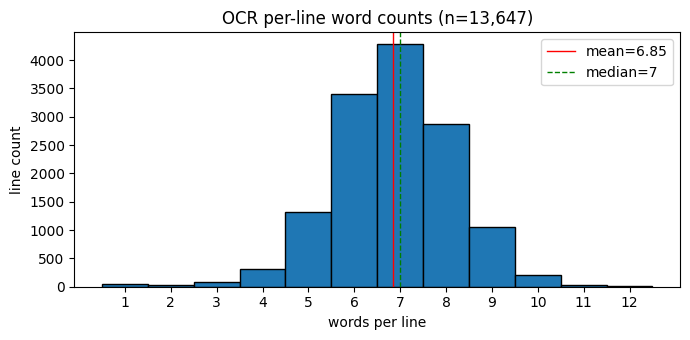

In [4]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(arr, bins=np.arange(arr.min(), arr.max() + 2) - 0.5, edgecolor="black")
ax.axvline(summary["mean"], color="red", lw=1, label=f"mean={summary['mean']:.2f}")
ax.axvline(summary["median"], color="green", lw=1, ls="--", label=f"median={summary['median']:.0f}")
ax.set_xlabel("words per line")
ax.set_ylabel("line count")
ax.set_title(f"OCR per-line word counts (n={arr.size:,})")
ax.legend()
ax.set_xticks(np.arange(arr.min(), arr.max() + 1))
plt.tight_layout()
plt.show()

### 5. Save lengths + summary to JSON

Saved as a sortable list of per-line word counts. The medical-texts
categorization script reads this file and samples from `lengths` to
decide how many words go in each pseudo-line.

In [5]:
stamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
out_path = OUT_DIR / f"ocr_line_lengths_{stamp}.json"
doc = {
    "source_dir": str(OCR_DIR.relative_to(PROJECT_ROOT)),
    "timestamp": datetime.datetime.now().isoformat(timespec="seconds"),
    "summary": summary,
    "lengths": counts,
}
out_path.write_text(json.dumps(doc, indent=2, ensure_ascii=False))
print(f"wrote {out_path.relative_to(PROJECT_ROOT)} ({out_path.stat().st_size / 1024:.1f} KB)")

wrote tests/ocr/ocr_line_lengths_20260625_120230.json (94.0 KB)
